In [1]:
import os, sys, torch, numpy as np, pandas as pd
import alphashape
from shapely.geometry import LineString

from tqdm import tqdm
from sklearn.decomposition import PCA
from torch.nn.functional import softmax
from scipy.linalg import orthogonal_procrustes

sys.path.append('../../../')
from polygene.model.model import load_trained_model
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
from polygene.data_utils.tokenization import normalise_str

EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_geometry/vectors/'
torch.manual_seed(3)
device = 'cuda:0'

mod, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")
mod.to(device).eval()
decoder = mod.prediction_head

n_grad = 30
surround_border = 20
whiten=False
stabilizing_eps = 1e-6  # stabilizing coefficient pulling the metric toward the Euclidean identity

log_partition_function = lambda xi: torch.log( torch.sum( torch.exp( xi ) ) )

# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
def riemannian_metric(z, decoder):
    jacobian_decoder = torch.func.jacfwd(decoder)(z)
    hessian_log_partition = torch.func.hessian(log_partition_function)(decoder(z))
    G = jacobian_decoder.T @ hessian_log_partition @ jacobian_decoder
    return G

results = {}
for file_path in os.listdir(EMBEDDINGS_DIR):
    if "embeddings.pkl" not in file_path:
        continue
    #if "small cell" not in file_path and "large" not in file_path: continue

    saved_embeddings = pd.read_pickle(os.path.join(EMBEDDINGS_DIR, file_path))
    df = pd.DataFrame({'embedding': saved_embeddings[0].tolist()} | {tok.phenotypic_types[i]: saved_embeddings[2][:, i] for i in range(len(tok.phenotypic_types))})
    disease_list = sorted(df['disease'].unique().tolist(), key=lambda x: 0 if 'normal' in x else 1)

    proj = PCA(2, whiten=whiten, svd_solver="full")
    df[['x','y']] = proj.fit_transform(np.array(df['embedding'].tolist())).tolist()
    explained_var = proj.explained_variance_ratio_.copy()

    x_min, x_max = df['x'].min()-surround_border, df['x'].max()+surround_border
    y_min, y_max = df['y'].min()-surround_border, df['y'].max()+surround_border
    xg, yg = np.linspace(x_min, x_max, n_grad), np.linspace(y_min, y_max, n_grad)
    X, Y = np.meshgrid(xg, yg)

    phase_space_pca_coordinates = np.stack([X, Y], axis=-1).reshape(-1, 2)
    phase_space_embeddings = proj.inverse_transform(phase_space_pca_coordinates)

    gradients_per_embedding = []
    riemannian_gradients_per_embedding = []
    for embedding in tqdm(phase_space_embeddings, desc=file_path + " - Gradients"):
        embedding = torch.tensor(embedding, device=device, dtype=torch.float32, requires_grad=True)

        metric = riemannian_metric(embedding, decoder)
        stable_metric = 0.5*(metric + metric.T) + stabilizing_eps*torch.eye(metric.shape[0],device=metric.device) # well conditionned, non singular.
        inverse_metric = torch.linalg.inv(stable_metric).detach().cpu().numpy()

        probabilities = softmax(decoder(embedding.unsqueeze(0)), dim=1).squeeze(0)
        gradients_per_disease = []
        for disease in disease_list:
            probability_of_disease = probabilities[tok.token_to_id_map[normalise_str(disease)]]
            decoder.zero_grad(set_to_none=True)
            probability_of_disease.backward(retain_graph=True)
            gradients_per_disease.append(embedding.grad.detach().cpu().numpy())
            embedding.grad.zero_()
        gradients_per_embedding.append(np.array(gradients_per_disease))
        riemannian_gradients_per_embedding.append( np.array(gradients_per_disease) @ inverse_metric )

    gradients = np.array(gradients_per_embedding).reshape(-1, phase_space_embeddings.shape[-1])
    grad_proj = PCA(2, whiten=whiten, svd_solver="full").fit(gradients)
    R, _ = orthogonal_procrustes(grad_proj.components_.T, proj.components_.T)
    phase_space_gradients = (grad_proj.transform(gradients) @ R).reshape(phase_space_embeddings.shape[0], len(disease_list), 2)
    riemannian_phase_space_gradients = (grad_proj.transform(np.array(riemannian_gradients_per_embedding).reshape(-1, phase_space_embeddings.shape[-1])
                                ) @ R).reshape(phase_space_embeddings.shape[0], len(disease_list), 2)

    alpha = 0.1 # controls concave hull setting
    #alpha = 0.5 # controls concave hull setting
    shape = alphashape.alphashape(df[['x','y']].to_numpy(), alpha=alpha)
    curve = LineString(shape.exterior.coords)
    curve_coords = np.array([curve.interpolate(d, normalized=True).coords[0] for d in np.linspace(0, 1, 30)])
    hull_gradients, riemann_hull_gradients = [], []
    for coords in curve_coords:
        hull_embedding = torch.tensor(proj.inverse_transform(coords.reshape(1, -1)), device=device, dtype=torch.float32).requires_grad_(True)
        probability_of_disease = softmax(decoder(hull_embedding), dim=1).squeeze()[tok.token_to_id_map[normalise_str(disease_list[-1])]]
        decoder.zero_grad()
        probability_of_disease.backward(retain_graph=True)

        metric = riemannian_metric(hull_embedding[0], decoder)
        stable_metric = 0.5*(metric + metric.T) + stabilizing_eps*torch.eye(metric.shape[0],device=metric.device) # well conditionned, non singular.
        inverse_metric = torch.linalg.inv(stable_metric).detach().cpu().numpy()

        hull_gradients.append( hull_embedding.grad.detach().cpu().numpy()[0] )
        riemann_hull_gradients.append( hull_embedding.grad.detach().cpu().numpy()[0] @ inverse_metric )
        hull_embedding.grad.zero_()

    hull_gradients_pca = (grad_proj.transform(np.array(hull_gradients)) @ R)
    V = hull_gradients_pca
    a = np.einsum('ij,ij->i', V, np.roll(V,-1,axis=0)) # cosine part 
    b = V[:,0]*np.roll(V,-1,axis=0)[:,1] - V[:,1]*np.roll(V,-1,axis=0)[:,0] # sine part
    winding_number = np.sum(np.arctan2(b,a))/(2*np.pi) 
    absolute_winding_number = np.sum(np.abs(np.arctan2(b,a)))/(2*np.pi) 
    
    riemann_hull_gradients_pca = (grad_proj.transform(np.array(riemann_hull_gradients)) @ R)
    V = riemann_hull_gradients_pca
    a = np.einsum('ij,ij->i', V, np.roll(V,-1,axis=0)) # cosine part 
    b = V[:,0]*np.roll(V,-1,axis=0)[:,1] - V[:,1]*np.roll(V,-1,axis=0)[:,0] # sine part
    riemann_winding_number = np.sum(np.arctan2(b,a))/(2*np.pi) 
    absoute_riemann_winding_number = np.sum(np.abs(np.arctan2(b,a)))/(2*np.pi) 

    results[file_path.split('_')[0]] = {
        "meshgrid": (X, Y),
        "gradients": phase_space_gradients.reshape(n_grad, n_grad, len(disease_list), 2),
        "riemannian_gradients": riemannian_phase_space_gradients.reshape(n_grad, n_grad, len(disease_list), 2),
        "df": df,
        "explained_var": explained_var,
        "surround_border": surround_border,
        "n_grad": n_grad,
        "fill_coordinates": shape.exterior.xy,
        "hull_coords": curve_coords,
        "hull_gradients": hull_gradients_pca,
        "winding_number": winding_number,
        "riemann_hull_gradients": riemann_hull_gradients_pca,
        "riemann_winding_number": riemann_winding_number,
        "absolute_winding_number": absolute_winding_number,
        "absolute_riemann_winding_number": absoute_riemann_winding_number
    }
    #break

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
small cell lung carcinoma_embeddings.pkl - Gradients: 100%|██████████| 900/900 [00:04<00:00, 199.10it/s]
lung large cell carcinoma_embeddings.pkl - Gradients: 100%|██████████| 900/900 [00:03<00:00, 231.69it/s]
non-small cell lung carcinoma_embeddings.pkl - Gradients: 100%|██████████| 900/900 [00:03<00:00, 228.98it/s]
glioblastoma_embeddings.pkl - Gradients: 100%|██████████| 900/900 [00:03<00:00, 231.07it/s]


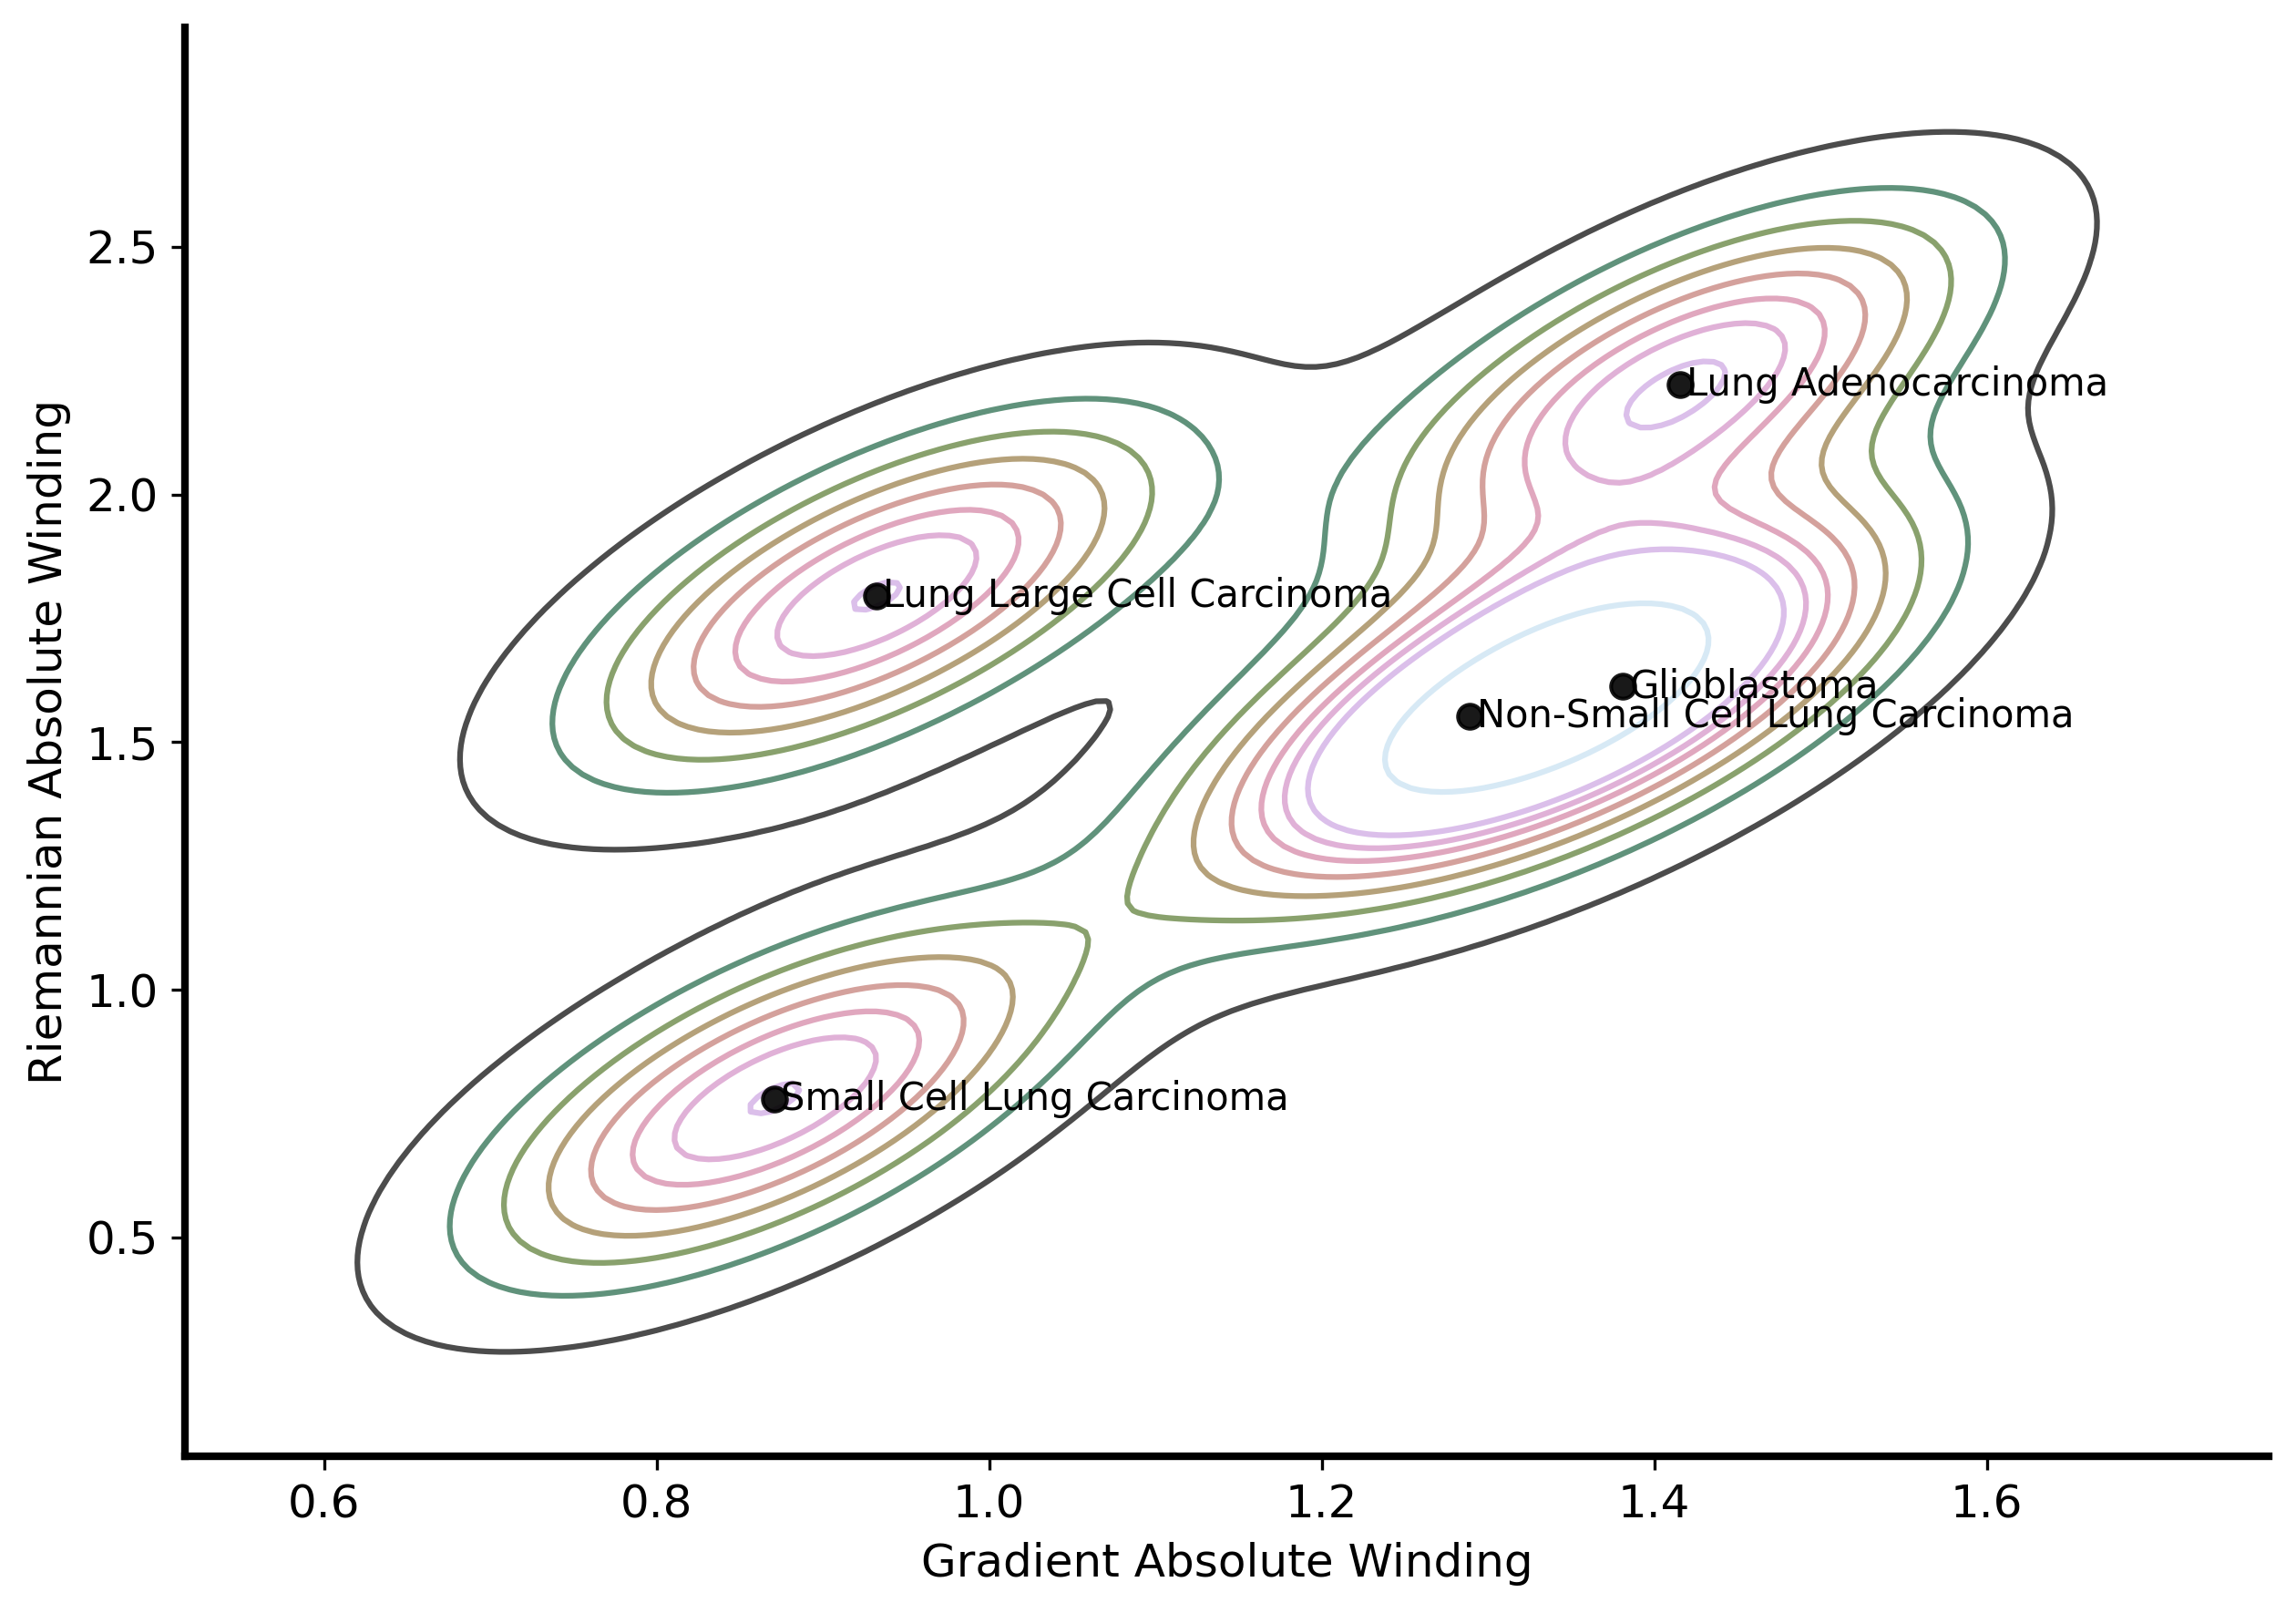

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import PowerNorm

fontsize = 12
dpi = 300

# --- collect per-disease metrics from results dict ---
metrics_df = (
    pd.DataFrame.from_dict(
        {
            disease: {
                "grad_abs_winding": float(r["absolute_winding_number"]),
                "riemann_abs_winding": float(r["absolute_riemann_winding_number"]),
            }
            for disease, r in results.items()
        },
        orient="index",
    )
    .reset_index()
    .rename(columns={"index": "disease"})
)

# optional: exclude anything you consider "raw" / auxiliary
metrics_df = metrics_df[~metrics_df["disease"].str.lower().str.contains("raw", na=False)].copy()

# --- annotate subset (same logic style as your previous plot) ---
disease_selection = ("gastr", "park", "dementia", "alz", "norm", "plasma", "carci")
annotated = [
    d for d in metrics_df["disease"].tolist()
   # if any(s in d.lower() for s in disease_selection) and ("renal" not in d.lower())
]

df_annotated = metrics_df[metrics_df["disease"].isin(annotated)].copy()
df_rest = metrics_df[~metrics_df["disease"].isin(annotated)].copy()
df_annotated["disease"] = df_annotated["disease"].apply(lambda x: x.title())

# --- plot: gradient absolute winding vs riemannian absolute winding ---
plt.figure(figsize=(8.5, 6), dpi=dpi)

sns.kdeplot(
    x=metrics_df["grad_abs_winding"],
    y=metrics_df["riemann_abs_winding"],
    levels=10,
    fill=False,
    cmap="cubehelix",
    alpha=0.7,
    zorder=-1,
    bw_adjust=0.6,
    linewidths=1.5,
    norm=PowerNorm(gamma=0.5),
)

plt.scatter(
    df_rest["grad_abs_winding"],
    df_rest["riemann_abs_winding"],
    s=40,
    alpha=0.4,
    color="grey",
    zorder=0,
)
plt.scatter(
    df_annotated["grad_abs_winding"],
    df_annotated["riemann_abs_winding"],
    s=40,
    alpha=0.9,
    color="k",
    zorder=1,
)

ax = plt.gca()
x_unit = np.diff(ax.get_xticks())[0] if len(ax.get_xticks()) > 1 else (metrics_df["grad_abs_winding"].std() or 1.0)
y_unit = np.diff(ax.get_yticks())[0] if len(ax.get_yticks()) > 1 else (metrics_df["riemann_abs_winding"].std() or 1.0)

xlim = (
    metrics_df["grad_abs_winding"].min() - x_unit / 1.5,
    metrics_df["grad_abs_winding"].max() + x_unit / 1.5,
)
ylim = (
    metrics_df["riemann_abs_winding"].min() - y_unit / 3,
    metrics_df["riemann_abs_winding"].max() + y_unit / 3,
)
#plt.xlim(xlim)
#plt.ylim(ylim)

for _, row in df_annotated.iterrows():
    yoffset = 0 if "Dem" not in row["disease"] else -y_unit / 20
    plt.annotate(
        row["disease"],
        (row["grad_abs_winding"] + x_unit / 50, row["riemann_abs_winding"] + yoffset),
        fontsize=fontsize - 2,
        va="center",
        ha="left",
        fontweight="500",
    )

plt.xlabel("Gradient Absolute Winding", fontsize=fontsize)
plt.ylabel("Riemannian Absolute Winding", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

ax.spines[["left", "bottom"]].set_linewidth(2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
#plt.savefig("../figures/figure3/abs_winding_vs_riemann_abs_winding.png", dpi=dpi, transparent=False)
#plt.savefig("../figures/figure3/abs_winding_vs_riemann_abs_winding.svg", dpi=dpi, transparent=True)
plt.show()


In [ ]:
import os, sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

SAVE=False
fontsize=12
step=1

scale=0.5
width=0.0035

for idx, disease in enumerate(results):
    for jdx, disease_index in enumerate([0, 1, 1, 1]):
        if jdx < 2: continue
        disease_results = results[disease]
        X,Y=disease_results['meshgrid']
        explained_var=disease_results['explained_var']
        phase_space_gradients=disease_results["gradients"] if jdx < 3 else disease_results["riemannian_gradients"]
        df=disease_results['df']
        surround_border, n_grad=disease_results['surround_border'], disease_results['n_grad']
      
        fig,ax=plt.subplots(1,1,figsize=(5.5,5),dpi=600)

        g_norm = phase_space_gradients / np.linalg.norm(phase_space_gradients,axis=-1,keepdims=True)

        #g_norm = phase_space_gradients / np.log(1 + np.linalg.norm(phase_space_gradients,axis=-1,keepdims=True))

        gx,gy=g_norm[:,:,disease_index,0],g_norm[:,:,disease_index,1]

        ax.quiver(X[::step,::step],Y[::step,::step],gx[::step,::step],gy[::step,::step],color='gray' if jdx < 3 else 'tab:blue',
                  alpha=.9,scale_units='xy',scale=scale,width=width,headwidth=3,headlength=5,headaxislength=4,zorder=-5)

        sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=sns.color_palette('Paired',n_colors=20)[2:],s=5,alpha=0.5,ax=ax,linewidth=0,zorder=1)
        ax.set_xticklabels([]);ax.set_yticklabels([])
        ax.spines[['top','right']].set_linewidth(0);ax.spines[['bottom','left']].set_linewidth(2)
        ax.set_xlim(df['x'].min()-surround_border,df['x'].max()+surround_border);ax.set_ylim(df['y'].min()-surround_border,df['y'].max()+surround_border)
        ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)',fontsize=fontsize-2);ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)',fontsize=fontsize-2)

        if jdx >= 2:
            winding_number = disease_results['winding_number']  if jdx < 3 else disease_results["riemann_winding_number"]
            turning_number = disease_results['absolute_winding_number']  if jdx < 3 else disease_results["absolute_riemann_winding_number"]

            ax.text(0.05, 0.95, f"Total Curvature (Turning) = {turning_number:.2f}", fontfamily='serif', transform=ax.transAxes, fontsize=fontsize-2, ha='left', va='center',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='white', pad=3))
            ax.fill(*disease_results['fill_coordinates'],facecolor=(0.1, 0.8, 0.1, 0.05), edgecolor=(0.1, 0.6, 0.1, 0.5), linewidth=3, label='$\\alpha$-shape', zorder=-10)

            curve_coords = disease_results['hull_coords']
            hull_gradients_pca = disease_results['hull_gradients']  if jdx < 3 else disease_results["riemann_hull_gradients"]
            hull_gradients_pca /= np.linalg.norm(hull_gradients_pca,axis=-1,keepdims=True)
            ax.quiver(curve_coords[:,0], curve_coords[:,1], hull_gradients_pca[:,0],hull_gradients_pca[:,1], color='green',
                       alpha=1, scale_units='xy', scale=scale/1.5, width=width+0.001, headwidth=3, headlength=5, headaxislength=4,zorder=100)

        handles,legend_labels_=ax.get_legend_handles_labels()
        arrow_gray=FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color="gray" if jdx <3 else 'tab:blue',linewidth=1)
        def make_handle(legend,orig_handle,xdescent,ydescent,width,height,fontsize):
            return FancyArrowPatch((0,height*0.5),(width,height*0.5),arrowstyle='-|>', mutation_scale=fontsize,color=orig_handle.get_edgecolor() if hasattr(orig_handle,'get_edgecolor') else orig_handle.get_facecolor(),linewidth=1)
        handles.append(arrow_gray)
        legend_labels_.append(f"Gradient Flow\n$\partial_i p ({['normal', 'disease'][disease_index]} | z)$") if jdx < 3 else     legend_labels_.append("Riemannian Flow \n$ g^{ij} \partial_j p (disease | z)$")
        legend_labels_ = [' '.join([word.capitalize() for word in x[1:-1].split('_')]).replace(' Right Ventricular', '').replace("Small Cell Lung Carcinoma", "SCLC").replace("Non Small Cell Lung Carcinoma", "NSCLC").replace("Lung Large Cell Carcinoma", "LCLC")
                            if '[' in x else x for x in legend_labels_]
        legend_labels_ = [x.replace(' ', '\n') if len(x) > 17 and "\n" not in x else x for x in legend_labels_]
        #legend=ax.legend(np.array(handles).tolist(),np.array(legend_labels_).tolist(),frameon=True,bbox_to_anchor=(1,1),borderaxespad=0.5,edgecolor='none',framealpha=0.8,fontsize=fontsize-2,handler_map={FancyArrowPatch:HandlerPatch(patch_func=make_handle)})
        legend = ax.legend(handles, legend_labels_, frameon=True, #bbox_to_anchor=(1,1),
                        borderaxespad=0.5, edgecolor='none', framealpha=0.8, loc="upper right",
                        fontsize=fontsize-2, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_handle)})
        for h in legend.legendHandles:
            if hasattr(h,"set_markersize"): h.set_markersize(6); h.set_alpha(1)
        
        plt.tight_layout()
        plt.savefig(f'../figures/figure5_turn/{disease}_{disease_index}_{jdx}.png', dpi=600)
        plt.show()
        #break

In [ ]:
results['glioblastoma']['rieman']

In [ ]:
fontsize = 12

import os, sys
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
from matplotlib.ticker import ScalarFormatter

EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_geometry/vectors/'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

for file_path in os.listdir(EMBEDDINGS_DIR):
    if "geometry" not in file_path: continue
    stats = pd.read_pickle(os.path.join(EMBEDDINGS_DIR, file_path))
    disease = file_path.split('_')[0]
    X, Y = stats['meshgrid']
    explained_var = stats['explained_var']
    phase_space_gradients = stats["gradients"]
    phase_space_gradients = results[disease]['riemannian_gradients']
    surround_border, n_grad = stats['surround_border'], stats['n_grad']
    df, geometry_df = stats['df'], stats['geometrical_stats']
    jacobian_field, step = 1, 1
    geometry_df['healthy_gradient_norm'] = np.linalg.norm(phase_space_gradients, axis=-1)[:, :, 0].ravel()
    geometry_df['disease_gradient_norm'] = np.linalg.norm(phase_space_gradients, axis=-1)[:, :, 1].ravel()

    x_min, x_max = df['x'].min() - surround_border, df['x'].max() + surround_border
    y_min, y_max = df['y'].min() - surround_border, df['y'].max() + surround_border

    metrics = ['ricci_curvature', 'amari_norm', 'levi_civita_norm', 'anistropy_ratio', 'spectral_entropy', 'log_volume']
    metrics = ['amari_norm', 'levi_civita_norm', 'anistropy_ratio', 'spectral_entropy', 'log_volume']
    #metrics = [ 'anistropy_ratio', 'spectral_entropy', 'log_volume', 'levi_civita_norm]
    eq = {
        'ricci_curvature': "Curvature of Ricci Tensor",
        'amari_norm': "Amari-Chentsov Tensor Norm: $||T_{ijk}||_F$",
        'levi_civita_norm': "Levi-Civita Connection Norm: $||\Gamma^i_{jk}||_F$",
        'anistropy_ratio': "Fisher Information $G = U \Lambda U^{\\top}$\nCondition Number: $\lambda_{max}/\lambda_{min}$",
        'spectral_entropy': "Fisher Information $G = U \Lambda U^{\\top}$\nSpectral Entropy: $H(softmax (\lambda))$",
        'log_volume': "Fisher Information $G = U \Lambda U^{\\top}$\nLog Volume: $\log(\\sqrt{\\det(G)})$"
    }

    for metric_name in metrics:
        fig, ax = plt.subplots(1, 1, figsize=(6.75, 5), dpi=600)
        fig.set_constrained_layout(False)
        heatmap_stat = np.array(geometry_df[metric_name].tolist()).reshape(n_grad, n_grad)
        norm_grad = phase_space_gradients / np.linalg.norm(phase_space_gradients, axis=-1, keepdims=True)
        gx, gy = norm_grad[:, :, jacobian_field, 0], norm_grad[:, :, jacobian_field, 1]



        scale=0.5
        width=0.0035

        cmap = "vlag" if metric_name == "ricci_curvature" else "Blues"
        ax.quiver(X[::step, ::step], Y[::step, ::step], gx[::step, ::step], gy[::step, ::step], color="tab:blue", alpha=1, scale_units='xy',
                scale=scale, width=width, headwidth=3, headlength=5, headaxislength=4, zorder=-3)
        im = ax.imshow(heatmap_stat, extent=[x_min, x_max, y_min, y_max], origin='lower', aspect='auto', alpha=.75, zorder=-2, cmap=cmap)
        sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=sns.color_palette('Paired',n_colors=20)[2:],s=5,alpha=0.5,ax=ax,linewidth=0,zorder=1)

        ax.set_xticklabels([]); ax.set_yticklabels([])
        ax.spines[['top','right']].set_linewidth(0)
        ax.spines[['bottom','left']].set_linewidth(2)
        ax.set_xlim(df['x'].quantile(.01)-surround_border, df['x'].quantile(.99)+surround_border)
        ax.set_ylim(df['y'].quantile(.01)-surround_border, df['y'].quantile(.99)+surround_border)
        ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)', fontsize=fontsize-2)
        ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)', fontsize=fontsize-2)
        ax.set_title(eq.get(metric_name, metric_name.replace('_', ' ').title()), fontsize=fontsize-2)

        handles, legend_labels_ = ax.get_legend_handles_labels()
        arrow_proxy = FancyArrowPatch((0, 0), (1, 0), arrowstyle='-|>', mutation_scale=15, color="tab:blue", linewidth=1)
        def make_legend_quiver(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
            return FancyArrowPatch((0, height*0.5), (width, height*0.5),
                                arrowstyle='-|>', mutation_scale=fontsize, color="gray", linewidth=1)
        handles.append(arrow_proxy)
        #legend_labels_.append("Gradient Flow\n$\partial_i p (disease | z)$")
        legend_labels_.append("Riemannian Flow \n$ g^{ij} \partial_j p (disease | z)$")
        legend_labels_ = [' '.join([word.capitalize() for word in x[1:-1].split('_')]).replace(' Right Ventricular', '').replace(' Right Ventricular', '').replace("Small Cell Lung Carcinoma", "SCLC").replace("Non SCLC", "NSCLC").replace("Lung Large Cell Carcinoma", "LCLC")
                        if '[' in x else x for x in legend_labels_]
        legend_labels_ = [x.replace(' ', '\n') if len(x) > 17 and "\n" not in x else x for x in legend_labels_]
        legend = ax.legend(handles, legend_labels_, frameon=True, #bbox_to_anchor=(1,1),
                        borderaxespad=0.5, edgecolor='none', framealpha=0.8, loc="upper right",
                        fontsize=fontsize-2, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_quiver)})
        for handle in legend.legendHandles:
            if hasattr(handle, "set_markersize"):
                handle.set_markersize(6)
                handle.set_alpha(1)

        cbar = fig.colorbar(im, ax=ax, shrink=0.4, aspect=15, pad=0.04)
        cbar.solids.set_alpha(1)
        cbar.set_label('\n'.join(metric_name.split('_')).title(), fontsize=fontsize-2, labelpad=25, rotation=0, va="center", ha="center")

        cbar.ax.tick_params(labelsize=fontsize-2)
        formatter = ScalarFormatter(useMathText=False)
        formatter.set_powerlimits((-2, 3))
        cbar.ax.yaxis.set_major_formatter(formatter)
        offset = cbar.ax.yaxis.get_offset_text()
        offset.set_x(2.5); offset.set_y(0); offset.set_fontsize(fontsize-2)
        plt.tight_layout()
        #pos = cbar.ax.get_position()
        #cbar.ax.set_position([pos.x0, pos.y0-0.12, pos.width, pos.height])

        #if SAVE:
        plt.savefig(f"../figures/figure5_turn/phase_space_{file_path.split('.')[0]}_{metric_name}.png", dpi=600)
        plt.show()
    

In [ ]:
import os, sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

SAVE=False
fontsize=12
disease_index=1
step=1

scale_grad = 3
scale_tangent = 3

width=0.004
log_norm_factor = 0.01

for disease_idx, disease in enumerate(results): 
    disease_results = results[disease]
    X,Y=disease_results['meshgrid']
    explained_var=disease_results['explained_var']
    phase_space_gradients=disease_results["gradients"]
    tangent_field=disease_results["riemannian_gradients"]
    df=disease_results['df']
    surround_border, n_grad=disease_results['surround_border'], disease_results['n_grad']

    fig,ax=plt.subplots(1,1,figsize=(6,4),dpi=600)

    g_norm=phase_space_gradients / np.linalg.norm(phase_space_gradients,axis=-1,keepdims=True)
    tg_norm=tangent_field / np.linalg.norm(tangent_field,axis=-1,keepdims=True)

    #g_norm = phase_space_gradients / np.log(1 + 0.5*np.linalg.norm(phase_space_gradients,axis=-1,keepdims=True))
    #tg_norm = tangent_field / np.log(1 + log_norm_factor*np.linalg.norm(tangent_field,axis=-1,keepdims=True))

    gx,gy=g_norm[:,:,disease_index,0],g_norm[:,:,disease_index,1]
    tx,ty=tg_norm[:,:,disease_index,0],tg_norm[:,:,disease_index,1]

    #ax.quiver(X[::step,::step],Y[::step,::step],gx[::step,::step],gy[::step,::step],color='gray',alpha=.6,scale_units='xy',scale=scale_grad,width=width,headwidth=3,headlength=5,headaxislength=4,zorder=0)
    ax.quiver(X[::step,::step],Y[::step,::step],tx[::step,::step],ty[::step,::step],color='tab:blue',alpha=.9,scale_units='xy',scale=scale_tangent,width=width,headwidth=3,headlength=5,headaxislength=4,zorder=0)

    sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=sns.color_palette('Paired',n_colors=20)[2:],s=5,alpha=0.5,ax=ax,linewidth=0,zorder=1)
    ax.set_xticklabels([]);ax.set_yticklabels([])
    ax.spines[['top','right']].set_linewidth(0);ax.spines[['bottom','left']].set_linewidth(2)
    ax.set_xlim(df['x'].min()-surround_border,df['x'].max()+surround_border);ax.set_ylim(df['y'].min()-surround_border,df['y'].max()+surround_border)
    ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)',fontsize=fontsize-2);ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)',fontsize=fontsize-2)

    handles,legend_labels_=ax.get_legend_handles_labels()
    arrow_gray=FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color="gray",linewidth=1)
    arrow_blue=FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color="tab:blue",linewidth=1)
    def make_handle(legend,orig_handle,xdescent,ydescent,width,height,fontsize):
        return FancyArrowPatch((0,height*0.5),(width,height*0.5),arrowstyle='-|>', mutation_scale=fontsize,color=orig_handle.get_edgecolor() if hasattr(orig_handle,'get_edgecolor') else orig_handle.get_facecolor(),linewidth=1)
    #handles.append(arrow_gray); 
    handles.append(arrow_blue)
    #legend_labels_.append("Gradient Flow\n$\partial_i p (disease | z)$"); 
    legend_labels_.append("Riemannian Flow \n$ g^{ij} \partial_j p (disease | z)$")
    legend_labels_ = [' '.join([word.capitalize() for word in x[1:-1].split('_')]).replace(' Right Ventricular', '').replace("Small Cell Lung Carcinoma", "SCLC").replace("Non SCLC", "NSCLC").replace("Lung Large Cell Carcinoma", "LCLC")
                        if '[' in x else x for x in legend_labels_]
    legend_labels_ = [x.replace(' ', '\n') if len(x) > 17 and "\n" not in x else x for x in legend_labels_]
    legend=ax.legend(np.array(handles).tolist(),np.array(legend_labels_).tolist(),frameon=True,bbox_to_anchor=(1,1),borderaxespad=0.5,edgecolor='none',framealpha=0.8,fontsize=fontsize-2,handler_map={FancyArrowPatch:HandlerPatch(patch_func=make_handle)})
    
    for h in legend.legendHandles:
        if hasattr(h,"set_markersize"): h.set_markersize(6); h.set_alpha(1)
    
    plt.tight_layout()
    plt.savefig(f'../figures/figure5_lung/{disease}_riemann.png', dpi=600)
    #plt.show()
    #break